In [1]:
import requests
import pandas as pd
import io
import collections
from itertools import combinations
import networkx as nx
pd.options.display.max_colwidth = 100
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
#Importing useful function. For details, check the associated course

!wget https://raw.githubusercontent.com/Yquetzal/Teaching_notebooks/main/Networks/HALfunctions.py
from HALfunctions import get_all_elements, co_occurence_network,co_occurence_network_laboratory,column_most_common,bi_partite_network,bi_partite_network_generic

--2026-07-30 12:26:53--  https://raw.githubusercontent.com/Yquetzal/Teaching_notebooks/main/Networks/HALfunctions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9183 (9.0K) [text/plain]
Saving to: ‘HALfunctions.py’

HALfunctions.py     100%[===================>]   8.97K  --.-KB/s    in 0s      

2026-07-30 12:26:53 (80.7 MB/s) - ‘HALfunctions.py’ saved [9183/9183]



# Prepare the request

In [3]:
# Here, detail the request. This exmaple: articles whose abstract contains "easy",
# published between 2020 et 2022, at l'université de Lyon.

domain="UNIV-LYON/"
words="title_t:(easy)"
dates="[2020 TO 2022]"
columns="title_s,authFullName_s,structAcronym_s,structCountry_s,structAddress_s,structType_s,structName_s,level1_domain_s,keyword_s"

request = "http://api.archives-ouvertes.fr/search/"+domain+"?q="+words+"&fq=publicationDate_s:"+dates+"&fl="+columns
simple_example = get_all_elements(request)
simple_example

Nombre d'éléments au total :  10
Éléments récupérés :  10


,title_s,authFullName_s,structAcronym_s,structCountry_s,structAddress_s,structType_s,structName_s,level1_domain_s,keyword_s
0,Standing on a Double-Seesaw Device is an Easy Way to Modify the Coordination Between the Two Fee...,"Patrice R. Rougier,Thibaud Coquard,Thierry Paillard,Clément Ankaoua,Jeanne Dury,Corentin Barthod...","LIBM,UCBL,UJM,UJM EPE,USMB [Université de Savoie] [Université de Chambéry],MEPS,UPPA,MPR,CHUGA","fr,fr,fr,fr,fr,fr,fr,fr,fr,fr",Faculté de Médecin Campus Santé Innovations - Bâtiment IRMIS - 10 rue de la Marandière 42270 Sai...,"laboratory,institution,regroupinstitution,institution,regroupinstitution,institution,laboratory,...","Laboratoire Interuniversitaire de Biologie de la Motricité,Université Claude Bernard Lyon 1,Univ...",sdv.neu,NaN
1,Easy Synthesis of Complex Biomolecular Assemblies: Wheat Germ Cell-Free Protein Expression in St...,"Marie-Laure Fogeron,Lauriane Lecoq,Laura Cole,Matthias Harbers,Anja Böckmann","MMSB,UCBL,CNRS,RIKEN IMS,RIKEN","fr,fr,fr,fr,jp,jp","IBCP CNRS/Université de Lyon7 Passage du vercors69367 LYON Cedex 07,43\, boulevard du 11 novembr...","laboratory,institution,regroupinstitution,regroupinstitution,institution,regroupinstitution",Microbiologie moléculaire et biochimie structurale - Molecular Microbiology and Structural Bioch...,"chim.anal,sdv.bbm,sdv.bbm","Labeling,NMR,Structural biology,Wheat germ,Cell-free protein expression"
2,"Mesurer la capacité de rétention en eau d’un sol par centrifugation : une méthode fiable\, facil...","Sandrine Revaillot,Célia Pouget,Gaël Alvarez,Sébastien Fontaine","UREP,VAS,INRAE,VAS","fr,fr,fr,fr","UREP - INRA Site de Crouel 5\, Chemin de Beaulieu 63039 CLERMONT FERRAND cedex 2,Université de L...","laboratory,institution,institution,institution","Unité Mixte de Recherche sur l'Ecosystème Prairial - UMR,VetAgro Sup - Institut national d'ensei...","sdv.sa,sdv.sa,spi.meca","Soil water content,Matrix pressure,Membrane press,Wilting point,Teneur en eau du sol,Pression ma..."
3,Easy mesh fixation to the promontory during sacrocolpopexy procedure,"G. Chene,A. Atallah,E. Cerruto,D Hallez,Y. Castori,E. Nohuz","EA3738,UCBL","fr,fr,fr",UFR Faculté de Médecin Lyon-Sud-Charles Mérieux BP12165 Chemin du Grand Revoyet69921 OULLINS Ced...,"laboratory,institution,regroupinstitution","Ciblage thérapeutique en Oncologie,Université Claude Bernard Lyon 1,Université de Lyon",NaN,NaN
4,New sonochemical magnetite nanoparticles functionalization approach of dithiooxamide–formaldehyd...,"Rahma Mehdaoui,Soumaya Agren,Abdelwahab Dhahri,Jamal El Haskouri,Emmanuel Beyou,Mohammed Lahcini...","IMP,UCBL,INSA Lyon,INSA,UJM,UJM EPE,INC-CNRS,CNRS,UM,UM6P,UCA","fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,tn,ma,ma","17\, Av. Jean Capelle 69621 Villeurbanne Cedex,43\, boulevard du 11 novembre 1918\, 69622 Villeu...","laboratory,institution,regroupinstitution,institution,regroupinstitution,regroupinstitution,inst...","Ingénierie des Matériaux Polymères,Université Claude Bernard Lyon 1,Université de Lyon,Institut ...",NaN,NaN
5,Easy way to perform salpingectomy by transvaginal natural orifice transluminal endoscopic surger...,"G. Chene,E. Nohuz,A. Mansoor,E. Cerruto,G. Lamblin,M. Galea,J. Baekelandt",UCBL,"fr,fr","43\, boulevard du 11 novembre 1918\, 69622 Villeurbanne cedex,92 rue Pasteur - CS 30122\, 69361 ...","institution,regroupinstitution","Université Claude Bernard Lyon 1,Université de Lyon",NaN,NaN
6,An easy control of the artificial numerical viscosity to get discrete entropy inequalities when ...,"Khaled Saleh,Arnaud Duran,Christophe Berthon","ICJ,ECL,UCBL,INSA Lyon,INSA,UJM,UJM EPE,CNRS,UCBL,MMCS,ICJ,ECL,UCBL,INSA Lyon,INSA,UJM,UJM EPE,C...","fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr,fr","Bât. Jean Braconnier 43 bd du 11 novembre 1918 69622 VILLEURBANNE CEDEX,36 avenue Guy de Collong...","laboratory,institution,regroupinstitution,institution,regroupinstitution,institution,regroupinst...","Institut Camille Jordan,École Centrale de Lyon,Universi

# Create co-occurence networks of elements in articles

In [4]:
# Network with nodes = authors, link if appear in same article
g1 = co_occurence_network(simple_example,"authFullName_s",threshold=0,threshold_max_in_col=10)

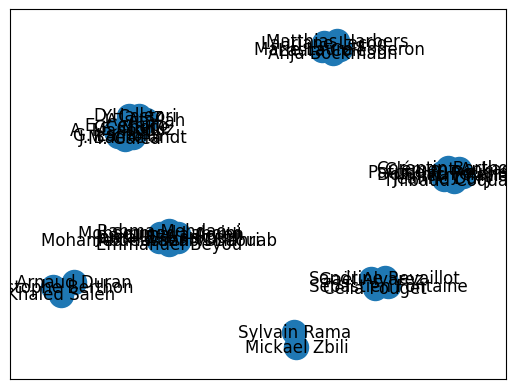

In [5]:
nx.draw_networkx(g1)

In [6]:
# Same, with keywords
g2 = co_occurence_network(simple_example,"keyword_s",threshold=0)

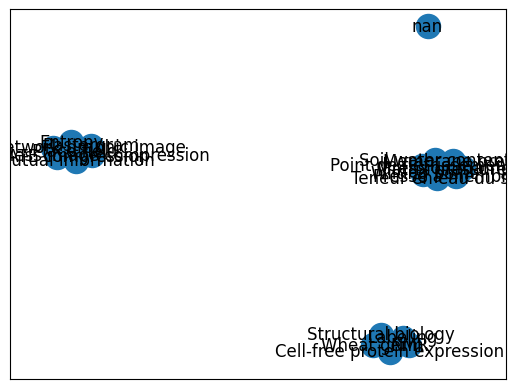

In [7]:
nx.draw_networkx(g2)

In [8]:
# Same, with scientific domains
g3 = co_occurence_network(simple_example,"level1_domain_s",threshold=0)

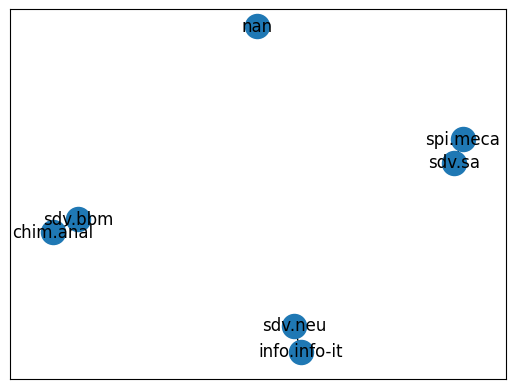

In [9]:
nx.draw_networkx(g3)

In [10]:
# Assigning an attribute to nodes
g_at = co_occurence_network(simple_example,"authFullName_s",threshold=0,attribute="level1_domain_s")

In [11]:
nx.get_node_attributes(g_at,"level1_domain_s")

{'Corentin Barthod': 'sdv.neu',
 'Dominic Pérennou': 'sdv.neu',
 'Patrice R. Rougier': 'sdv.neu',
 'Clément Ankaoua': 'sdv.neu',
 'Thibaud Coquard': 'sdv.neu',
 'Jeanne Dury': 'sdv.neu',
 'Thierry Paillard': 'sdv.neu',
 'Anja Böckmann': 'sdv.bbm',
 'Lauriane Lecoq': 'sdv.bbm',
 'Laura Cole': 'sdv.bbm',
 'Marie-Laure Fogeron': 'sdv.bbm',
 'Matthias Harbers': 'sdv.bbm',
 'Sébastien Fontaine': 'sdv.sa',
 'Sandrine Revaillot': 'sdv.sa',
 'Célia Pouget': 'sdv.sa',
 'Gaël Alvarez': 'sdv.sa',
 'D Hallez': 'nan',
 'Y. Castori': 'nan',
 'A. Atallah': 'nan',
 'E. Cerruto': 'nan',
 'E. Nohuz': 'nan',
 'G. Chene': 'nan',
 'Mohamed Hassen V. Baouab': 'nan',
 'Soumaya Agren': 'nan',
 'Jamal El Haskouri': 'nan',
 'Abdelwahab Dhahri': 'nan',
 'Rahma Mehdaoui': 'nan',
 'Emmanuel Beyou': 'nan',
 'Mohammed Lahcini': 'nan',
 'A. Mansoor': 'nan',
 'J. Baekelandt': 'nan',
 'G. Lamblin': 'nan',
 'M. Galea': 'nan',
 'Arnaud Duran': 'nan',
 'Khaled Saleh': 'nan',
 'Christophe Berthon': 'nan',
 'Sylvain Rama': 

# Bi-partite networks
Bi-partite networks have 2 types of nodes. A typical example is with articles as one type of nodes, and some element of the article as another type of nodes


In [12]:
# Bipartite network Article-authors
g5 = bi_partite_network_generic(simple_example,"title_s","authFullName_s")

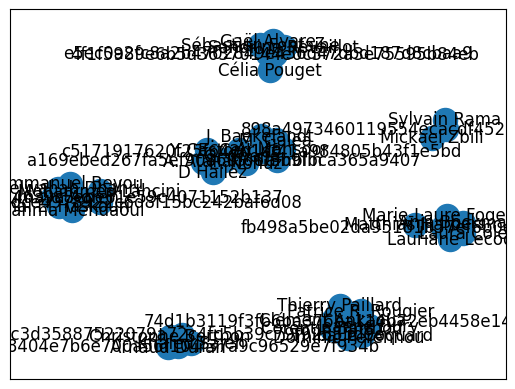

In [13]:
nx.draw_networkx(g5)

In [14]:
# Bipartite network Article-scientific domain
g5 = bi_partite_network_generic(simple_example,"title_s","level1_domain_s")

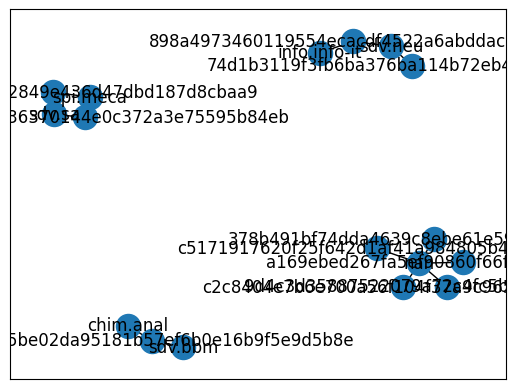

In [15]:
nx.draw_networkx(g5)

In [16]:
#domain - keywords
g6 = bi_partite_network_generic(simple_example,"level1_domain_s","keyword_s",threshold_max_in_col=10)


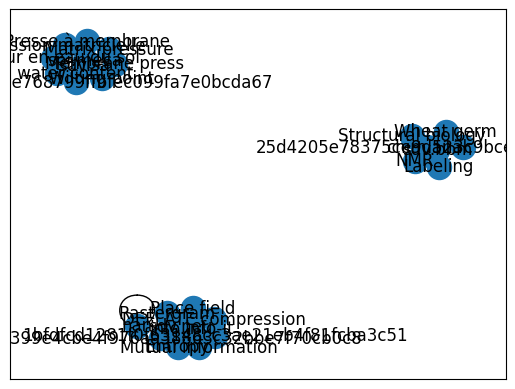

In [17]:
nx.draw_networkx(g6)

In [18]:
# to remove edges appearing less than k times
k=2
to_remove = [(a,b) for a, b, attrs in g6.edges(data=True) if attrs["occurrences"] <k]
g6.remove_edges_from(to_remove)
g6.remove_nodes_from(list(nx.isolates(g6)))

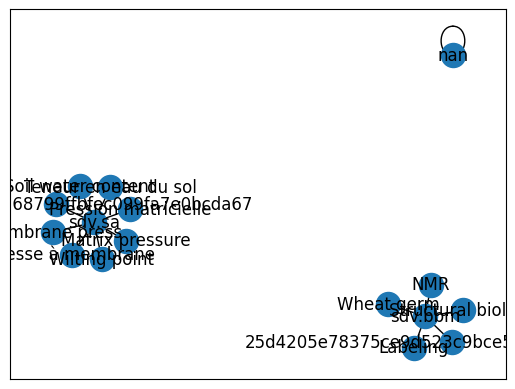

In [19]:
nx.draw_networkx(g6)

# Exporting file to open it in Gephi
With this command, you save the file in the current directory (same as this notebook). If you are in Google Colab, it will appear on the panel on your left (might need to refresh it).

In [20]:
nx.write_graphml(g1,"exemple1.graphml")
nx.write_graphml(g6,"exemple6.graphml")